# Fans most favorites genre analysis

In [10]:
import duckdb
import pandas as pd
import sys
import os

# 1. Aggiungi la cartella 'lib' al path di sistema per poter importare i tuoi moduli
# Assumendo che tu sia nel notebook o in uno script nella cartella principale
sys.path.append(os.path.abspath('lib'))

from lib.dbconnection import load_config, db_config, create_db_engine
# 2. Carica le variabili d'ambiente dal tuo file .env tramite il tuo modulo
load_config()

# 3. Configurazione DuckDB con l'estensione Postgres
con = duckdb.connect()
con.execute("INSTALL postgres; LOAD postgres;")

# Costruiamo la stringa di connessione usando i dati caricati dal tuo db_config
conn_string = (
    f"dbname={db_config['database']} "
    f"user={db_config['user']} "
    f"password={db_config['password']} "
    f"host={db_config['host']} "
    f"port={db_config['port']}"
)

con.execute(f"ATTACH '{conn_string}' AS anime_db (TYPE POSTGRES);")

# 4. Definisci i percorsi
ratings_path = '../../../cleaned_data/ratings_cleaned.parquet'

# 5. La Query (Federated: unisce Parquet locale e Postgres remoto)
query = f"""
    WITH user_scores AS (
        SELECT
            username,
            AVG(cast(score as int)) as mean_score
        FROM '{ratings_path}'
        GROUP BY username
    )
    SELECT
        p.username,
        p.completed,
        COALESCE(s.mean_score, 0) as mean_score
    FROM anime_db.profiles p
    LEFT JOIN user_scores s ON p.username = s.username
    WHERE p.completed IS NOT NULL
"""

# 6. Esecuzione
profiles = con.sql(query).df()

# FORZA LA CONVERSIONE: Trasforma 'completed' in numeri.
# Se ci sono valori sporchi, diventano NaN e vengono rimossi.
profiles['completed'] = pd.to_numeric(profiles['completed'], errors='coerce')
profiles = profiles.dropna(subset=['completed'])

# Ora qcut non darà più l'errore perché lavora su veri numeri
profiles['activity_level'] = pd.qcut(
    profiles['completed'],
    q=3,
    labels=['Novizio', 'Appassionato', 'Veterano']
)

print("Analisi completata con successo:")
# Traduzione inglese per le colonne nel print
summary = profiles.groupby('activity_level', observed=True)[['completed', 'mean_score']].mean()
summary.columns = ['Avg Completed', 'Avg Score']
print(summary)

Analisi completata con successo:
                Avg Completed  Avg Score
activity_level                          
Novizio             35.450955   3.865109
Appassionato       162.716022   4.123288
Veterano           462.555546   4.112114


In [11]:
# Recuperiamo i dati da Postgres (usa la tua funzione di connessione)
engine = create_db_engine()
df_details = pd.read_sql("SELECT mal_id, genres FROM public.details", engine)

# Pulizia dei generi: rimuoviamo la punteggiatura fastidiosa [ ] '
# Trasformiamo "['Action', 'Adventure']" in "Action, Adventure"
df_details['genres'] = df_details['genres'].astype(str).str.replace(r"[\[\]']", "", regex=True)

print("DataFrame df_details caricato e pulito con successo.")

## 1. Registra il dataframe pulito in DuckDB
con.register('df_details_clean', df_details)

# 2. Query per esplodere i generi e contare le occorrenze
query_genres = f"""
    WITH exploded_genres AS (
        SELECT
            unnest(string_split(d.genres, ',')) as genre,
            r.score
        FROM read_parquet('{ratings_path}') r
        JOIN df_details_clean d ON r.anime_id = d.mal_id
    )
    SELECT
        trim(genre) as Genre,
        COUNT(*) as Total_Views,
        ROUND(AVG(CAST(score AS DOUBLE)), 2) as Average_Score
    FROM exploded_genres
    WHERE genre IS NOT NULL AND genre != '' AND genre != 'None'
    GROUP BY Genre
    ORDER BY Total_Views DESC
    LIMIT 10
"""

df_popular_genres = con.sql(query_genres).df()

print("### TOP 10 MOST POPULAR GENRES ###")
print(df_popular_genres)

DataFrame df_details caricato e pulito con successo.
### TOP 10 MOST POPULAR GENRES ###
          Genre  Total_Views  Average_Score
0        Action     52878553           4.26
1       Fantasy     34788651           4.19
2       Romance     26567656           4.05
3        Comedy     25345926           3.90
4        Sci-Fi     17410482           3.85
5     Adventure     17074562           4.29
6  Supernatural     16618178           4.23
7        Comedy     15730446           4.24
8         Drama     15447400           4.39
9         Drama     13062958           4.11


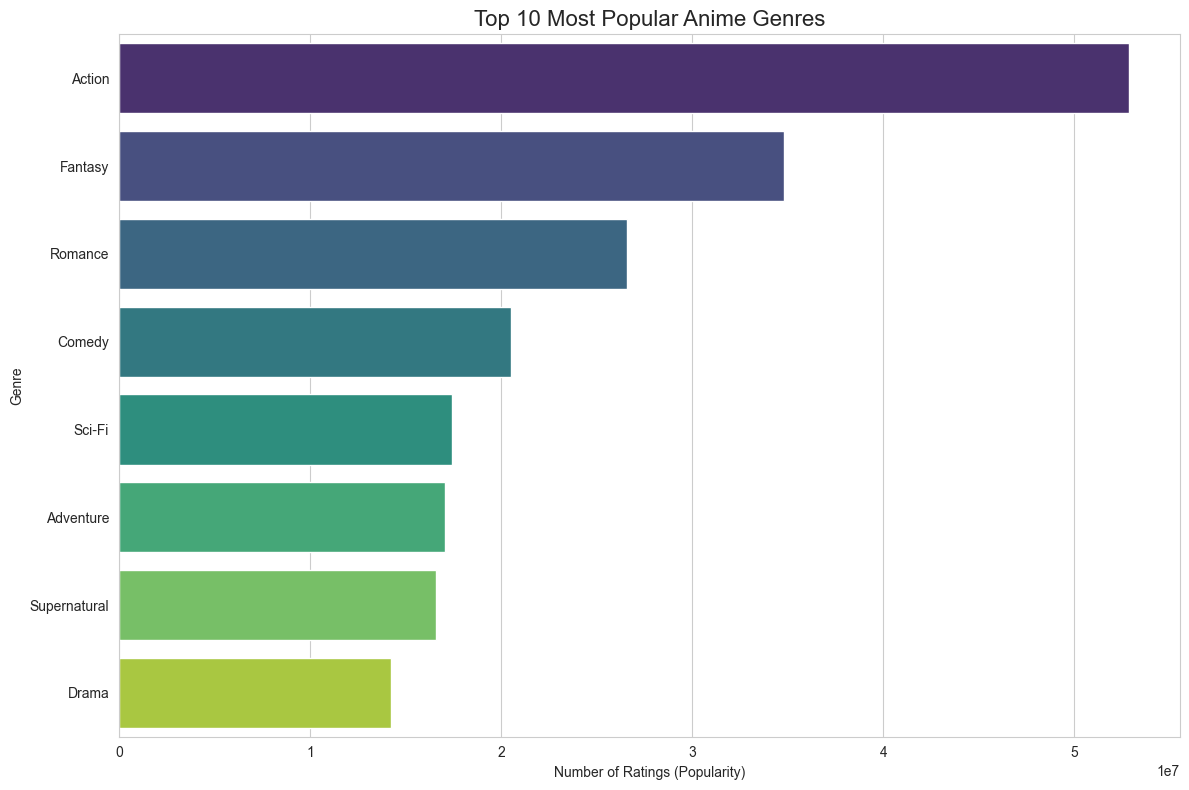

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

sns.barplot(
    data=df_popular_genres,
    x='Total_Views',
    y='Genre',
    hue='Genre',
    palette='viridis',
    legend=False,
    errorbar=None
)

plt.title('Top 10 Most Popular Anime Genres', fontsize=16)
plt.xlabel('Number of Ratings (Popularity)')
plt.ylabel('Genre')

plt.tight_layout()
plt.show()